In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from experiment_utils import run_one_experiment, save_result, run, MLPClassifier, save_result_v1

In [2]:
data = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_rankings_clean_filled.csv')
data.drop(columns=['Unnamed: 0'], inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  1239 non-null   str    
 1   home_team             1239 non-null   str    
 2   away_team             1239 non-null   str    
 3   home_score            1239 non-null   float64
 4   away_score            1239 non-null   float64
 5   tournament            1239 non-null   str    
 6   city                  1239 non-null   str    
 7   country               1239 non-null   str    
 8   neutral               1239 non-null   int64  
 9   year                  1239 non-null   int64  
 10  is_world_cup          1239 non-null   int64  
 11  is_qualifier          1239 non-null   int64  
 12  match_id              1239 non-null   int64  
 13  home_rank_date_used   1239 non-null   str    
 14  home_rank             1239 non-null   float64
 15  home_previous_rank    1239 non-n

In [3]:
X = data[['home_rank', 'away_rank', 'home_elo', 'away_elo']]
y = data['result']

In [4]:
label_mapping = {
    -1:0,
     0:1,
     1:2
}

X_train, X_test, y_train, y_test = train_test_split(X, y.map(label_mapping), test_size=0.2, random_state=42, shuffle = False)

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [6]:
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [8]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8019 | val loss = 0.7765 | val acc = 0.6432
Epoch 100/1000 | train loss = 0.7901 | val loss = 0.7803 | val acc = 0.6382
Epoch 150/1000 | train loss = 0.7812 | val loss = 0.7752 | val acc = 0.6332
Epoch 200/1000 | train loss = 0.7657 | val loss = 0.7738 | val acc = 0.6382
Epoch 250/1000 | train loss = 0.7556 | val loss = 0.7758 | val acc = 0.6332
Epoch 300/1000 | train loss = 0.7452 | val loss = 0.7806 | val acc = 0.6382
Epoch 350/1000 | train loss = 0.7519 | val loss = 0.7825 | val acc = 0.6382
Epoch 400/1000 | train loss = 0.7531 | val loss = 0.7845 | val acc = 0.6332
Epoch 450/1000 | train loss = 0.7326 | val loss = 0.7888 | val acc = 0.6432
Epoch 500/1000 | train loss = 0.7331 | val loss = 0.7938 | val acc = 0.6432
Epoch 550/1000 | train loss = 0.7340 | val loss = 0.8017 | val acc = 0.6432
Epoch 600/1000 | train loss = 0.7529 | val loss = 0.8081 | val acc = 0.6382
Epoch 650/1000 | train loss = 0.7394 | val loss = 0.8126 | val acc = 0.6332
Epoch 700/100

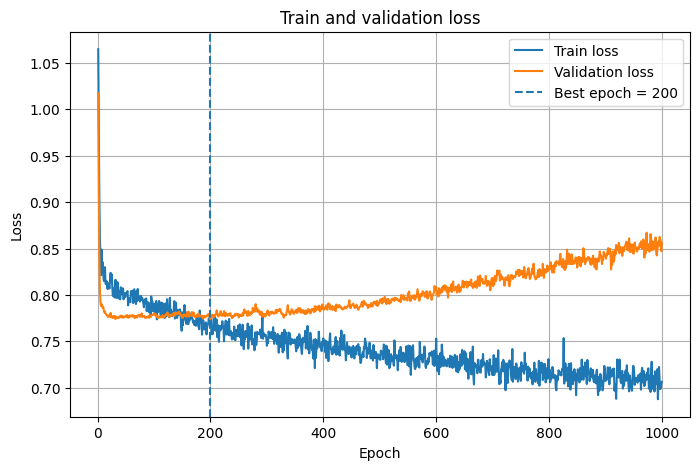

0.5725806451612904

In [9]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [10]:
best_num_epochs = 200

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5726 | Precision: 0.3903 | Recall: 0.4945 | Specificity: 0.7529 | F1: 0.4260

Run 2/10
Accuracy: 0.5605 | Precision: 0.3796 | Recall: 0.4815 | Specificity: 0.7462 | F1: 0.4138

Run 3/10
Accuracy: 0.5726 | Precision: 0.3903 | Recall: 0.4945 | Specificity: 0.7529 | F1: 0.4260

Run 4/10
Accuracy: 0.5726 | Precision: 0.3850 | Recall: 0.4966 | Specificity: 0.7549 | F1: 0.4261

Run 5/10
Accuracy: 0.5605 | Precision: 0.3805 | Recall: 0.4794 | Specificity: 0.7455 | F1: 0.4120

Run 6/10
Accuracy: 0.5726 | Precision: 0.3863 | Recall: 0.4987 | Specificity: 0.7549 | F1: 0.4283

Run 7/10
Accuracy: 0.5685 | Precision: 0.3862 | Recall: 0.4916 | Specificity: 0.7511 | F1: 0.4230

Run 8/10
Accuracy: 0.5605 | Precision: 0.3805 | Recall: 0.4794 | Specificity: 0.7455 | F1: 0.4120

Run 9/10
Accuracy: 0.5685 | Precision: 0.3862 | Recall: 0.4916 | Specificity: 0.7511 | F1: 0.4230

Run 10/10
Accuracy: 0.5806 | Precision: 0.5582 | Recall: 0.5081 | Specificity: 0.7610 | F1: 0.4560

Summary o

In [11]:
save_result(
    experiment_name="Experiment_1-5_FIFA_and_ELO_ranks",
    summary=summary
)

save_result_v1(
    experiment_name="Experiment_1-5_FIFA_and_ELO_ranks",
    summary=summary
)


Saved result for Experiment_1-5_FIFA_and_ELO_ranks
File: ../results/experiment_summary_final.csv

Saved result for Experiment_1-5_FIFA_and_ELO_ranks
File: ../results/experiment_summary_v1.csv
